## 4장 1강: 파이토치 기초 및 심층 신경망

### 6. 파이토치 기반 패션 이미지 다층 모델 실습
#### 6.1 데이터 준비 및 전처리
실습에 필요한 도구 불러오기 및 설정

In [1]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device(
    'cuda' if torch.cuda.is_available() else # NVIDIA
    'mps' if torch.backends.mps.is_available() else # MAC
    'cpu' 
)

print(f'현재 사용중인 연산 디바이스 : {device}')

현재 사용중인 연산 디바이스 : mps


Fashion MNIST 데이터 불러오기

In [2]:
# Fashion MNIST 28 X 28[2차원] ( 0 ~ 255 ) -> 표준 점수 -> 특성은 1차원으로 변환
# 60000 -> 훈련 데이터는 50,000장, 검증 10,000장

# 훈련 데이터 셋
raw_train_data = datasets.FashionMNIST(
    root='data', train=True, download=True, transform=ToTensor()
)

# 테스트 데이터 셋
test_data = datasets.FashionMNIST(
    root='data', train=False, download=True, transform=ToTensor()
)


In [3]:
# 검증 데이터 셋 분리
train_size = 50000
val_size = 10000

train_data, val_data = random_split(
    raw_train_data, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)


print(f'훈련 셋 : {len(train_data)}')
print(f'검증 셋 : {len(val_data)}')
print(f'테스트 셋 : {len(test_data)}')

훈련 셋 : 50000
검증 셋 : 10000
테스트 셋 : 10000


In [4]:
# 데이터 세트별 DataLoader 생성
# batch_size = 에포크에서 전 데이터셋을 32개의 배치로 분할
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [5]:
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1529, 0.2353, 0.2000,
           0.2235, 0.1961, 0.2157, 0.2078, 0.1961, 0.1922, 0.1647, 0.1725,
           0.1804, 0.1843, 0.2353, 0.0431],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0078, 0.0000, 0.5216, 0.6196, 0.5922,
           0.7529, 0.7725, 0.8118, 0.7882, 

### 6.2 모델 설계

다층 퍼셉트론(MLP) 모델 클래스 정의

In [6]:
import torch.nn as nn
import torch.optim as optim

class AdvancedFashionClassifier(nn.Module):
    # 사용할 층(Layer)을 정의
    def __init__(self):
        super().__init__()

        # (28, 28) -> 특성은 1차원으로 변경 (784,)
        # nn.Flatten() -> 2차원 텐서 -> 1차원 텐서 - 입력층
        self.flatten = nn.Flatten()

        # 은닉층 ( 784 -> 128 )
        self.hidden_layer = nn.Linear(784, 128)

        # 활성화 함수 (ReLU)
        self.relu = nn.ReLU()

        # Dropout - 0 ~ 1, 0.2 ~ 0.5
        self.dropout = nn.Dropout(p=0.2)

        # 출력층 128 -> 10
        self.output_layer = nn.Linear(128, 10)

    # 순전파(Feed Forward)
    def forward(self, x):
        out = self.flatten(x) # 28 X 28 -> 784 # 입력층 처리
        out = self.hidden_layer(out) # 784 -> 128 # 은닉층 처리
        out = self.relu(out) # 활성화 함수 통과 (선형적 -> 비선형적)
        out = self.dropout(out) # 훈련시에만 필요, 과대적합 방지 ( 128, )
        out = self.output_layer(out) # 128 -> 10 출력층

        return out


모델 인스턴스 생성 및 연산 디바이스(GPU/MPS/CPU)로 할당

In [7]:
model = AdvancedFashionClassifier().to(device) # device에 지정된 기기로 연결

total_params = sum(p.numel() for p in  model.parameters() if p.requires_grad)
print(f'학습 가능한 총 모델 파라미터 개수 : {total_params:,}개')

학습 가능한 총 모델 파라미터 개수 : 101,770개


손실 함수 및 옵티마이저 정의


In [8]:
# 손실 함수
criterion = nn.CrossEntropyLoss()

# 옵티마이저
optimizer = optim.Adam(model.parameters(), lr=0.005)

### 6.3 조기 종료 학습 및 검증 루프

In [17]:
epochs = 20 # 최대 에포크
patience = 3 # 검증 로스가 더이상 떨어지지 않는 횟수, 3회 이상이면 학습 조기 종료
patience_count = 0
best_val_loss = float('inf')

train_losses = []
val_losses = []

for epoch in range(epochs):
    running_loss = 0.0 # 한 에포크(각 배치의 모든 손실)의 손실
    model.train() # 학습 모드 ( 학습에 필요한 것들 활성 - ex) Dropout )

    for images, labels in train_loader: # 미니배치 (32개씩)
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # 이전 기울기 초기화

        # 순방향 예측
        outputs = model(images) # 순방향

        # 손실 계산
        loss = criterion(outputs, labels)

        # 오차 역전파 수행 -> 기울기 구하기
        loss.backward()

        # 옵티마이저를 통한 가중치 업데이트
        optimizer.step()

        running_loss += loss.item() # 배치마다의 로스를 기록 (1에포크)

    epoch_loss = running_loss / len(train_loader) # 1에포크당 로스 (배치 로스의 평균)
    train_losses.append(epoch_loss)

    # 검증 모드
    model.eval() # 평가시에는 학습시에 필요한 부분 배제 -> [ Dropout, 기울기 업데이트 ]
    val_loss = 0.0

    with torch.no_grad(): # 검증시에는 기울기를 구하지 않음, 학습 관련 연산 하지 않음
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            # 검증 예측 ( 순전파 )
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)


    print(f'Epoch : {epoch + 1}/{epochs} | 훈련 loss : {epoch_loss:.4f}, 검증 로스 : {val_loss:.4f}')

    # 조기 종료
    if epoch_val_loss < best_val_loss :
        # 기존 검증 로스보다 개선이 됨
        best_val_loss = epoch_val_loss
        patience_count = 0

        # 손실이 개선된 모델 저장
        torch.save(model.state_dict(), 'best_fashion_model.pth')

    else : # 기존 검증 로스보다 개선 안됨
        patience_count += 1
        print(f'== 검증 손실 미개선 : {patience_count}/{patience} == ')

        # patience 한계 초과 시에 학습 중단 ( 조기 종료 )
        if patience_count >= patience :
            print(f'조기 종료 : {epoch+1} 에포크에서 학습 종료')
            break

Epoch : 1/20 | 훈련 loss : 0.3743, 검증 로스 : 120.3011
Epoch : 2/20 | 훈련 loss : 0.3695, 검증 로스 : 121.0742
== 검증 손실 미개선 : 1/3 == 
Epoch : 3/20 | 훈련 loss : 0.3688, 검증 로스 : 126.1119
== 검증 손실 미개선 : 2/3 == 
Epoch : 4/20 | 훈련 loss : 0.3592, 검증 로스 : 119.1867
Epoch : 5/20 | 훈련 loss : 0.3615, 검증 로스 : 129.0227
== 검증 손실 미개선 : 1/3 == 
Epoch : 6/20 | 훈련 loss : 0.3617, 검증 로스 : 123.6240
== 검증 손실 미개선 : 2/3 == 
Epoch : 7/20 | 훈련 loss : 0.3471, 검증 로스 : 129.1228
== 검증 손실 미개선 : 3/3 == 
조기 종료 : 7 에포크에서 학습 종료


In [12]:
val_losses[:5]

[0.40649748829226146,
 0.41832631345564564,
 0.40221252218602943,
 0.40482028114338653,
 0.40755351835165543]

### 6.4 최종 테스트셋 기반 정확도 측정 및 시각화

In [18]:
# 가장 좋은 가중치의 모델 불러오기
model.load_state_dict(torch.load('best_fashion_model.pth'))
model.to(device)

# 테스트 셋으로 평가
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) # 
        print(f'predicted : {predicted}')

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total * 100
print(f'테스트 셋 정확도 : {test_accuracy}')

predicted : tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4, 1, 2, 4, 8, 0, 2, 5, 7, 5,
        1, 2, 4, 0, 9, 3, 8, 8], device='mps:0')
predicted : tensor([3, 3, 8, 0, 7, 5, 7, 9, 0, 1, 6, 7, 6, 7, 2, 1, 2, 6, 4, 2, 5, 8, 2, 2,
        8, 4, 8, 0, 7, 7, 8, 5], device='mps:0')
predicted : tensor([1, 1, 6, 4, 7, 8, 7, 0, 6, 6, 4, 3, 1, 2, 8, 4, 1, 8, 5, 9, 5, 0, 3, 2,
        0, 6, 5, 3, 6, 7, 1, 8], device='mps:0')
predicted : tensor([0, 1, 6, 2, 3, 6, 7, 6, 7, 8, 5, 9, 9, 4, 2, 5, 7, 0, 5, 2, 8, 6, 7, 8,
        0, 0, 9, 9, 3, 0, 8, 2], device='mps:0')
predicted : tensor([1, 5, 4, 1, 9, 1, 8, 4, 2, 1, 2, 5, 1, 6, 0, 0, 1, 6, 1, 3, 2, 2, 2, 4,
        1, 3, 5, 0, 4, 7, 9, 3], device='mps:0')
predicted : tensor([7, 2, 3, 9, 0, 9, 4, 7, 4, 2, 6, 5, 2, 1, 2, 1, 3, 0, 9, 1, 0, 9, 3, 0,
        7, 9, 9, 4, 4, 7, 1, 2], device='mps:0')
predicted : tensor([3, 6, 3, 2, 8, 3, 6, 1, 1, 0, 2, 9, 2, 4, 0, 7, 9, 8, 4, 1, 8, 4, 1, 3,
        1, 6, 7, 4, 8, 5, 4, 0], device='mps:0')
predicted : t


=== 최종 테스트셋(실전 성능) 평가 시작 ===
최종 테스트 데이터셋 정확도(Test Accuracy): 86.27%


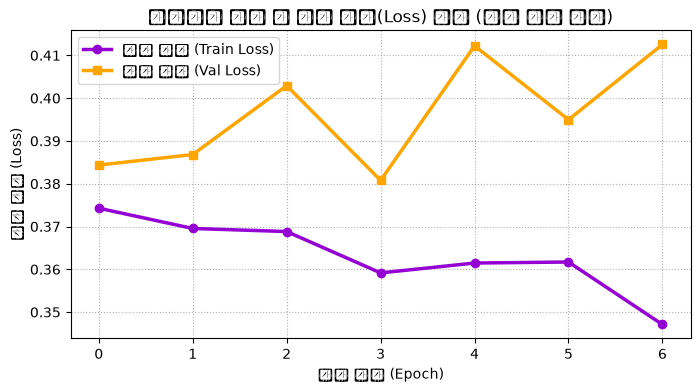

In [19]:
# 학습 과정 중 가장 성적이 좋았던 가중치 파일(pth) 복원
model.load_state_dict(torch.load("best_fashion_model.pth"))
model.to(device)

# 테스트셋 기반 최종 실전 정확도(Accuracy) 측정
model.eval()  # 추론 및 평가 모드로 고정
correct = 0
total = 0

print("\n=== 최종 테스트셋(실전 성능) 평가 시작 ===")
with torch.no_grad():  # 평가 단계이므로 미분 계산 비활성화
    for images, labels in test_loader:
        # 테스트 데이터셋 역시 연산 전 가속기로 이동시킵니다.
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        # 각 행(인스턴스)별로 10개 카테고리 중 가장 높은 점수를 받은 인덱스 추출
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)                       # 전체 데이터 개수 누적
        correct += (predicted == labels).sum().item()  # 정답을 맞춘 개수 누적

test_accuracy = 100 * correct / total
print(f"최종 테스트 데이터셋 정확도(Test Accuracy): {test_accuracy:.2f}%")

# 3. 에포크별 훈련 및 검증 손실 곡선 시각화
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker='o', color='darkviolet', linewidth=2.5, label='훈련 손실 (Train Loss)')
plt.plot(val_losses, marker='s', color='orange', linewidth=2.5, label='검증 손실 (Val Loss)')
plt.title("에포크별 훈련 및 검증 손실(Loss) 추이 (조기 종료 적용)")
plt.xlabel("학습 횟수 (Epoch)")
plt.ylabel("손실 크기 (Loss)")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()